# Unsupervised Learning Algorithms
Unsupervised learning algoritmaları, etiketlenmemiş verilerle çalışarak önceden tanımlanmış çıktılar olmadan gizli desenleri veya yapıları keşfeder. Bu algoritmalar üç ana kategoriye ayrılır: Kümeleme (Clustering), Boyut indirgeme (Dimensionality Reduction) ve Birliktelik Kuralları (Association Rule Mining).
Bu notebook'ta her bir algoritma grubunu örneklerle ve scikit-learn'in hazır veri setleriyle inceleyeceğiz.

## 1. Clustering (Kümeleme)
Kümeleme algoritmaları, veri noktalarını benzerliklerine göre gruplara ayırır. Amaç, veri içindeki doğal grupları bulmaktır. En yaygın kümeleme algoritmaları şunlardır:
- Centroid-based Methods (Merkez tabanlı): K-Means, K-Means++, K-Medoids, Fuzzy C-Means
- Distribution-based Methods (Dağılım tabanlı): Gaussian Mixture Models (GMM), Expectation-Maximization
- Connectivity-based Methods (Bağlantı tabanlı): Hierarchical Clustering (Agglomerative, Divisive), Affinity Propagation
- Density-based Methods (Yoğunluk tabanlı): DBSCAN, OPTICS

### Centroid-based Methods: K-Means Clustering
K-Means algoritması, veri noktalarını k adet kümeye ayırır ve her kümenin merkezini (centroid) bulmaya çalışır. scikit-learn'in hazır veri setlerinden Iris ile örnek gösterilecektir.

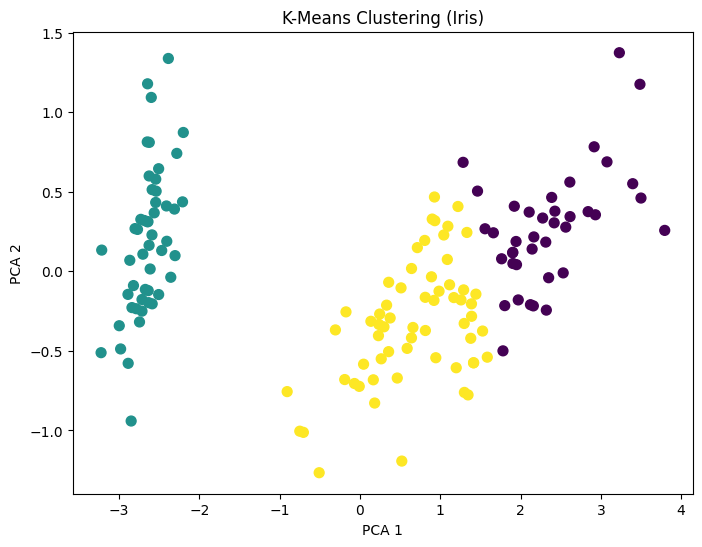

In [3]:
# K-Means Clustering örneği (Iris veri seti)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
iris = load_iris()
X = iris.data
kmeans = KMeans(n_clusters=3, random_state=42)
y_kmeans = kmeans.fit_predict(X)
# Görselleştirme için PCA ile 2 boyuta indir
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_kmeans, cmap='viridis', s=50)
plt.title('K-Means Clustering (Iris)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

### Distribution-based Methods: Gaussian Mixture Model (GMM)
Gaussian Mixture Model (GMM), veri noktalarını birden fazla Gauss dağılımına göre kümeler. Her veri noktasının bir kümeye ait olma olasılığı vardır.

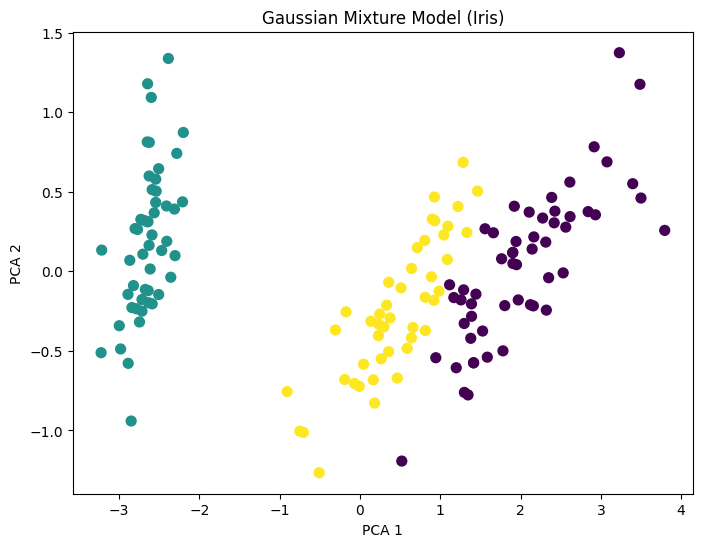

In [4]:
# Gaussian Mixture Model (GMM) örneği (Iris veri seti)
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=3, random_state=42)
y_gmm = gmm.fit_predict(X)
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_gmm, cmap='viridis', s=50)
plt.title('Gaussian Mixture Model (Iris)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

### Connectivity-based Methods: Hierarchical Clustering
Hierarchical Clustering, veri noktalarını hiyerarşik bir şekilde gruplar. Agglomerative (birleştirici) ve Divisive (bölücü) yöntemleri vardır.

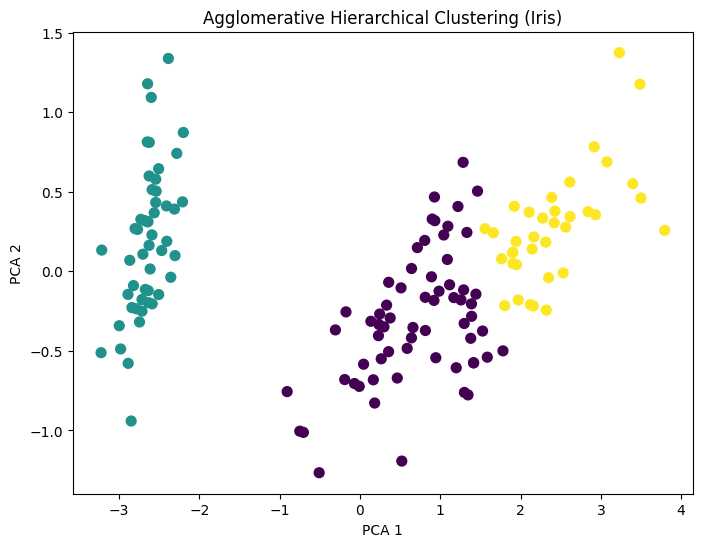

In [5]:
# Hierarchical Clustering (Agglomerative) örneği (Iris veri seti)
from sklearn.cluster import AgglomerativeClustering
agg = AgglomerativeClustering(n_clusters=3)
y_agg = agg.fit_predict(X)
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_agg, cmap='viridis', s=50)
plt.title('Agglomerative Hierarchical Clustering (Iris)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

### Density-based Methods: DBSCAN
DBSCAN algoritması, veri noktalarını yoğunluklarına göre kümeler ve aykırı değerleri (outlier) tespit edebilir.

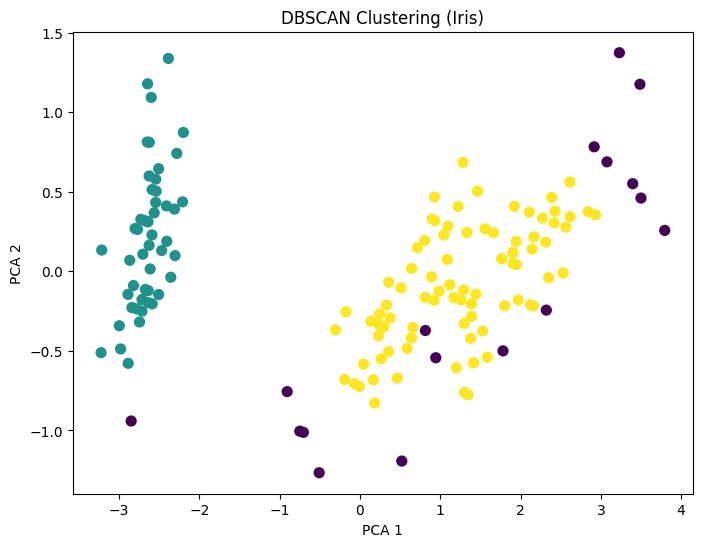

In [6]:
# DBSCAN örneği (Iris veri seti)
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
y_dbscan = dbscan.fit_predict(X)
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_dbscan, cmap='viridis', s=50)
plt.title('DBSCAN Clustering (Iris)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

## 2. Dimensionality Reduction (Boyut İndirgeme)
Boyut indirgeme algoritmaları, veri setindeki özellik sayısını azaltarak en önemli bilgiyi korumayı amaçlar. En yaygın yöntemler:
- Principal Component Analysis (PCA)
- t-distributed Stochastic Neighbor Embedding (t-SNE)
- Non-negative Matrix Factorization (NMF)
- Independent Component Analysis (ICA)
- Isomap
- Locally Linear Embedding (LLE)
- Latent Semantic Analysis (LSA)
- Autoencoders

### Principal Component Analysis (PCA)
PCA, veriyi en fazla varyansı açıklayan yeni eksenlere (principal components) dönüştürerek boyut indirgeme sağlar.

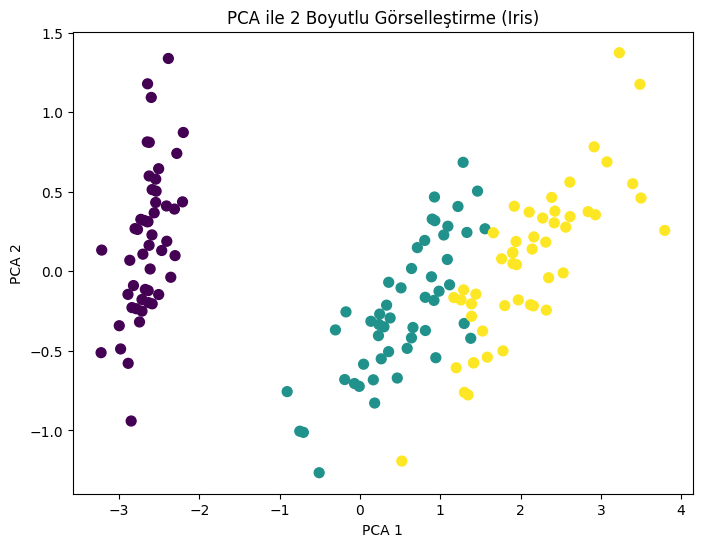

In [7]:
# PCA ile boyut indirgeme ve görselleştirme (Iris veri seti)
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X)
plt.figure(figsize=(8,6))
plt.scatter(X_pca2[:,0], X_pca2[:,1], c=iris.target, cmap='viridis', s=50)
plt.title('PCA ile 2 Boyutlu Görselleştirme (Iris)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

### t-distributed Stochastic Neighbor Embedding (t-SNE)
t-SNE, yüksek boyutlu verileri düşük boyutlara indirerek özellikle görselleştirme için kullanılır. Yerel ilişkileri korur.

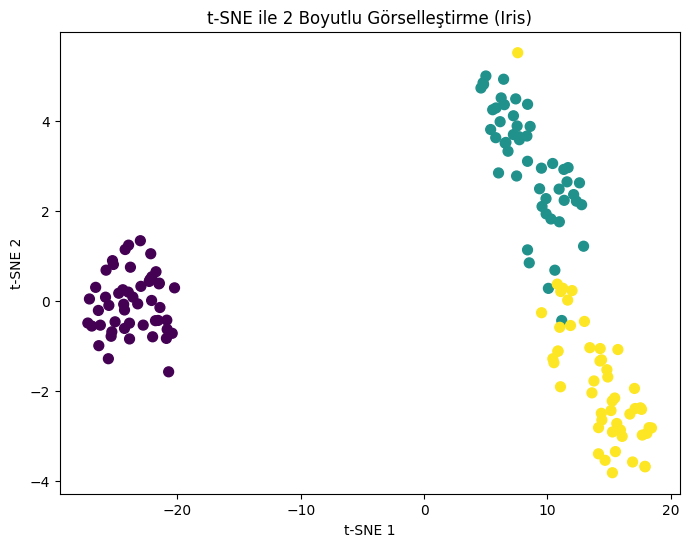

In [8]:
# t-SNE ile boyut indirgeme ve görselleştirme (Iris veri seti)
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)
plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=iris.target, cmap='viridis', s=50)
plt.title('t-SNE ile 2 Boyutlu Görselleştirme (Iris)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.show()

### Non-negative Matrix Factorization (NMF)
NMF, veriyi negatif olmayan bileşenlere ayırarak boyut indirgeme sağlar. Özellikle metin ve görüntü verilerinde kullanılır.

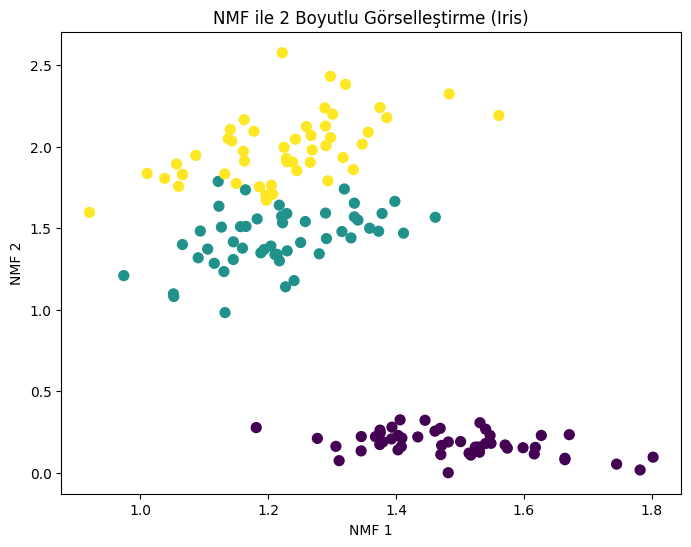

In [9]:
# NMF ile boyut indirgeme (Iris veri seti)
from sklearn.decomposition import NMF
nmf = NMF(n_components=2, init='random', random_state=42)
X_nmf = nmf.fit_transform(np.abs(X))
plt.figure(figsize=(8,6))
plt.scatter(X_nmf[:,0], X_nmf[:,1], c=iris.target, cmap='viridis', s=50)
plt.title('NMF ile 2 Boyutlu Görselleştirme (Iris)')
plt.xlabel('NMF 1')
plt.ylabel('NMF 2')
plt.show()

### Independent Component Analysis (ICA)
ICA, veriyi istatistiksel olarak bağımsız bileşenlere ayırır. Özellikle sinyal işleme ve kaynak ayrıştırmada kullanılır.

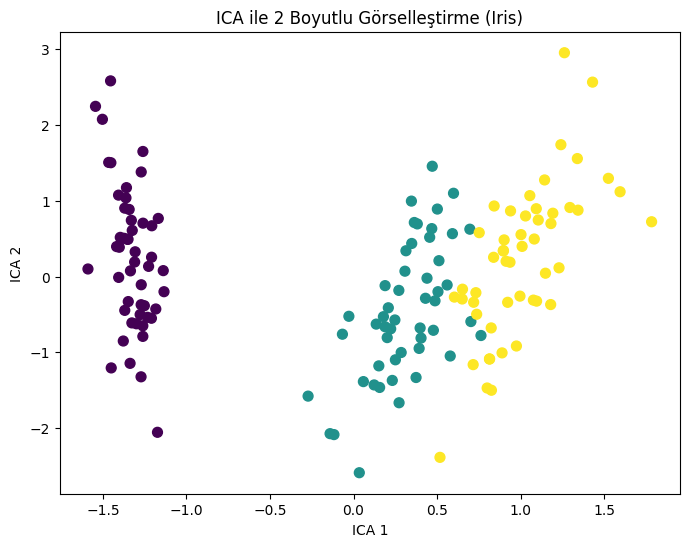

In [10]:
# ICA ile boyut indirgeme (Iris veri seti)
from sklearn.decomposition import FastICA
ica = FastICA(n_components=2, random_state=42)
X_ica = ica.fit_transform(X)
plt.figure(figsize=(8,6))
plt.scatter(X_ica[:,0], X_ica[:,1], c=iris.target, cmap='viridis', s=50)
plt.title('ICA ile 2 Boyutlu Görselleştirme (Iris)')
plt.xlabel('ICA 1')
plt.ylabel('ICA 2')
plt.show()

### Isomap
Isomap, verideki doğrusal olmayan yapıları koruyarak boyut indirgeme sağlar. Özellikle manifold öğrenmede kullanılır.

/home/yusuf/makineogrenmesi/.venv/lib/python3.12/site-packages/sklearn/manifold/_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/home/yusuf/makineogrenmesi/.venv/lib/python3.12/site-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


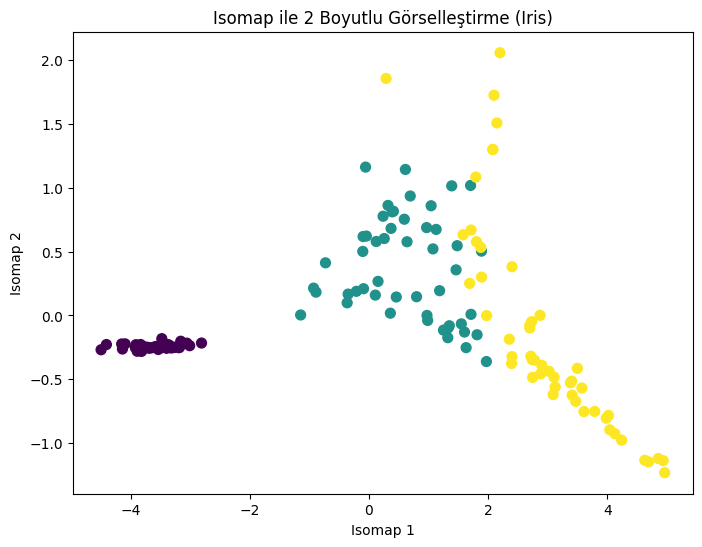

In [11]:
# Isomap ile boyut indirgeme (Iris veri seti)
from sklearn.manifold import Isomap
isomap = Isomap(n_components=2)
X_isomap = isomap.fit_transform(X)
plt.figure(figsize=(8,6))
plt.scatter(X_isomap[:,0], X_isomap[:,1], c=iris.target, cmap='viridis', s=50)
plt.title('Isomap ile 2 Boyutlu Görselleştirme (Iris)')
plt.xlabel('Isomap 1')
plt.ylabel('Isomap 2')
plt.show()

### Locally Linear Embedding (LLE)
LLE, veri noktalarını komşularına göre yeniden yapılandırarak boyut indirgeme sağlar. Yerel ilişkileri korur.

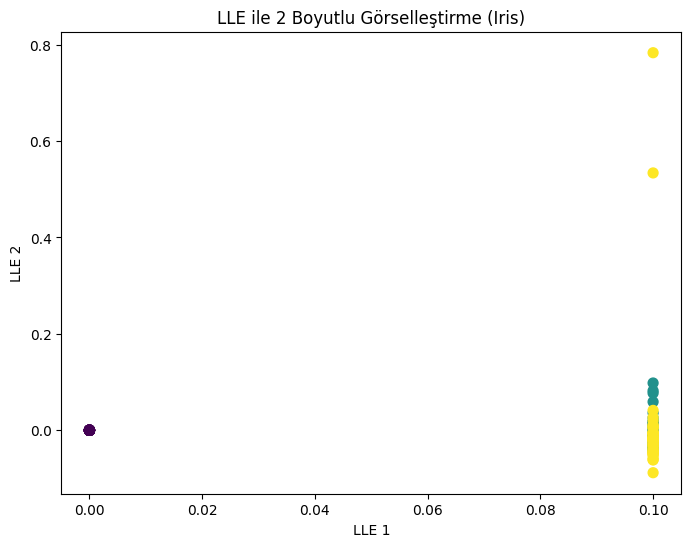

In [12]:
# LLE ile boyut indirgeme (Iris veri seti)
from sklearn.manifold import LocallyLinearEmbedding
lle = LocallyLinearEmbedding(n_components=2, random_state=42)
X_lle = lle.fit_transform(X)
plt.figure(figsize=(8,6))
plt.scatter(X_lle[:,0], X_lle[:,1], c=iris.target, cmap='viridis', s=50)
plt.title('LLE ile 2 Boyutlu Görselleştirme (Iris)')
plt.xlabel('LLE 1')
plt.ylabel('LLE 2')
plt.show()

### Latent Semantic Analysis (LSA)
LSA, metin verilerinde gizli anlamları ve ilişkileri ortaya çıkarmak için boyut indirgeme sağlar.

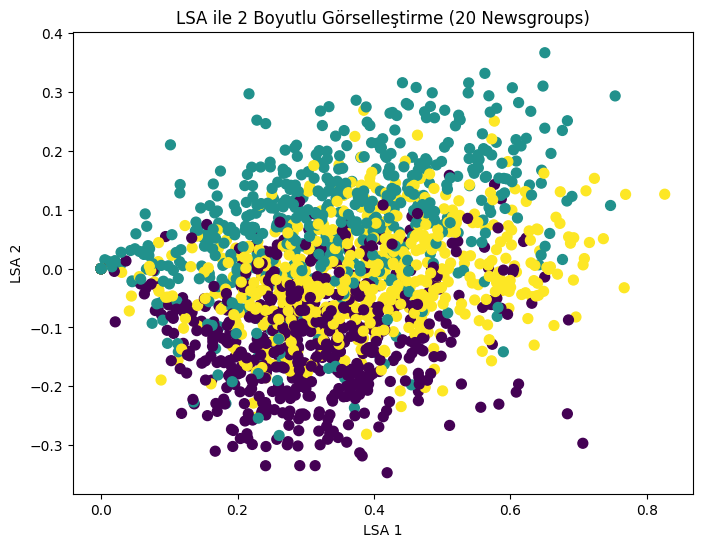

In [13]:
# LSA ile boyut indirgeme (20 Newsgroups metin veri seti)
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
newsgroups = fetch_20newsgroups(subset='train', categories=['sci.space','rec.sport.baseball','comp.graphics'], remove=('headers','footers','quotes'))
vectorizer = TfidfVectorizer(max_features=1000)
X_text = vectorizer.fit_transform(newsgroups.data)
lsa = TruncatedSVD(n_components=2, random_state=42)
X_lsa = lsa.fit_transform(X_text)
plt.figure(figsize=(8,6))
plt.scatter(X_lsa[:,0], X_lsa[:,1], c=newsgroups.target, cmap='viridis', s=50)
plt.title('LSA ile 2 Boyutlu Görselleştirme (20 Newsgroups)')
plt.xlabel('LSA 1')
plt.ylabel('LSA 2')
plt.show()

### Autoencoders
Autoencoderlar, veriyi sıkıştırıp yeniden oluşturan yapay sinir ağlarıdır. Özellikle derin öğrenmede boyut indirgeme ve anomali tespitinde kullanılır.

In [1]:
# Basit bir Autoencoder ile boyut indirgeme (Iris veri seti)
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
input_dim = X.shape[1]
encoding_dim = 2
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)
decoded = Dense(input_dim, activation='linear')(encoded)
autoencoder = Model(input_layer, decoded)
encoder = Model(input_layer, encoded)
autoencoder.compile(optimizer=Adam(learning_rate=0.01), loss='mse')
autoencoder.fit(X, X, epochs=100, batch_size=16, verbose=0)
X_encoded = encoder.predict(X)
plt.figure(figsize=(8,6))
plt.scatter(X_encoded[:,0], X_encoded[:,1], c=iris.target, cmap='viridis', s=50)
plt.title('Autoencoder ile 2 Boyutlu Görselleştirme (Iris)')
plt.xlabel('Encoded 1')
plt.ylabel('Encoded 2')
plt.show()

ModuleNotFoundError: No module named 'tensorflow'

## 3. Association Rule Mining (Birliktelik Kuralları)
Birliktelik kuralı algoritmaları, büyük veri kümelerinde öğeler arasındaki ilişkileri ve sık görülen desenleri bulur. En yaygın yöntemler:
- Apriori
- FP-Growth
- ECLAT

### Apriori Algoritması
Apriori algoritması, sık görülen öğe kümelerini ve bunlar arasındaki birliktelik kurallarını bulmak için kullanılır. Genellikle market sepeti analizi örneğiyle gösterilir.

### FP-Growth Algoritması
FP-Growth algoritması, sık öğe kümelerini hızlıca bulmak için FP-tree veri yapısını kullanır. Apriori'ye göre daha hızlıdır.

### ECLAT Algoritması
ECLAT algoritması, sık öğe kümelerini hızlıca bulmak için dikey veri formatı ve kümelerin kesişimini kullanır.